# Feature Engineering

Feature engineering is the process of using domain knowledge to create, transform, and select features that make machine learning algorithms work better. It is often the difference between a mediocre model and a great one.

> *"Applied machine learning is basically feature engineering."* Andrew Ng

---

## 1. Feature Scaling

Many algorithms (SVM, KNN, gradient descent-based) are sensitive to the scale of features.

### Standardization (Z-score normalization)
$$x' = \frac{x - \mu}{\sigma}$$
Result: mean=0, std=1. Sensitive to outliers.

### Min-Max Normalization
$$x' = \frac{x - x_{min}}{x_{max} - x_{min}}$$
Result: range [0,1]. Very sensitive to outliers.

### Robust Scaling
$$x' = \frac{x - Q_1}{Q_3 - Q_1}$$
Uses interquartile range robust to outliers.

### Box-Cox Transformation
$$y_\lambda = \begin{cases} \frac{x^\lambda - 1}{\lambda} & \text{if } \lambda \neq 0 \\ \ln(x) & \text{if } \lambda = 0 \end{cases}$$
Requires strictly positive values. Finds $\lambda$ via MLE.

### Yeo-Johnson Transformation
$$\psi(x, \lambda) = \begin{cases} \frac{(x+1)^\lambda - 1}{\lambda} & x \geq 0, \lambda \neq 0 \\ \ln(x+1) & x \geq 0, \lambda = 0 \\ -\frac{(-x+1)^{2-\lambda}-1}{2-\lambda} & x < 0, \lambda \neq 2 \\ -\ln(-x+1) & x < 0, \lambda = 2 \end{cases}$$
Works with negative values too.

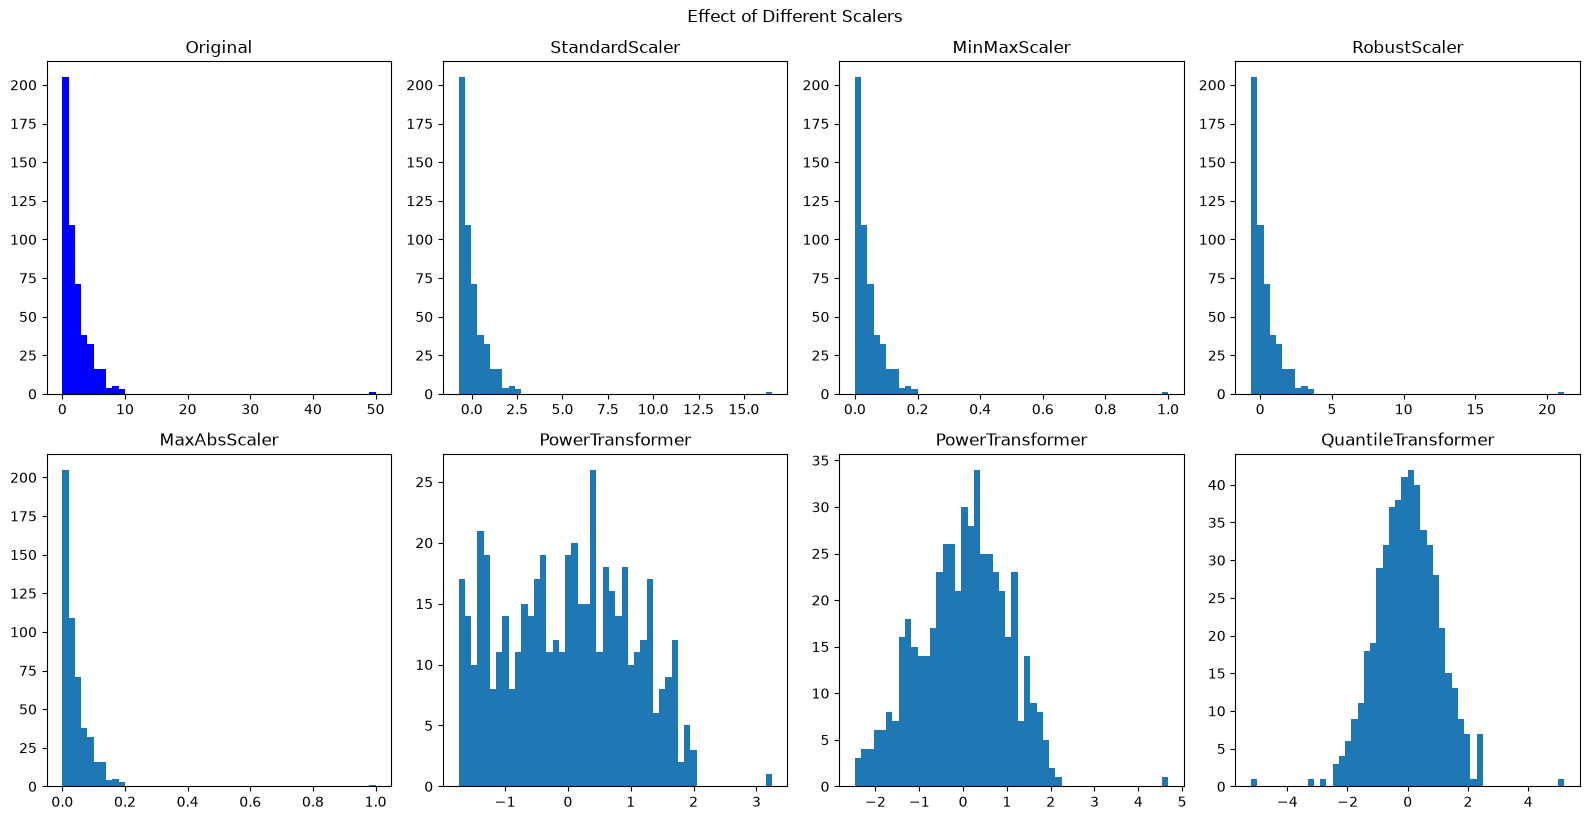

Scalers applied and visualized.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import (
    StandardScaler, MinMaxScaler, RobustScaler, MaxAbsScaler,
    PowerTransformer, QuantileTransformer, Normalizer
)
from sklearn.datasets import make_classification, load_iris
import warnings; warnings.filterwarnings('ignore')

# Create sample data with skewness and outliers
np.random.seed(42)
X_skewed = np.random.exponential(scale=2, size=(500, 1))
X_skewed[0] = 50  # outlier

scalers = {
    'StandardScaler': StandardScaler(),
    'MinMaxScaler': MinMaxScaler(),
    'RobustScaler': RobustScaler(),
    'MaxAbsScaler': MaxAbsScaler(),
    'PowerTransformer (Yeo-Johnson)': PowerTransformer(method='yeo-johnson'),
    'PowerTransformer (Box-Cox)': PowerTransformer(method='box-cox'),
    'QuantileTransformer (normal)': QuantileTransformer(output_distribution='normal', n_quantiles=100),
}

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes[0][0].hist(X_skewed, bins=50, color='blue'); axes[0][0].set_title('Original')
for idx, (name, scaler) in enumerate(scalers.items()):
    X_t = scaler.fit_transform(X_skewed)
    ax = axes[(idx+1)//4][(idx+1)%4]
    ax.hist(X_t, bins=50); ax.set_title(name.split('(')[0].strip())
plt.tight_layout(); plt.suptitle('Effect of Different Scalers', y=1.02); plt.show()
print("Scalers applied and visualized.")

---

## 2. Categorical Encoding

### Ordinal Encoding
Maps categories to integers: {cat: 0, dog: 1, bird: 2}. Implies ordering.

### One-Hot Encoding
Creates binary dummy variables. For $k$ categories: $k-1$ columns (drop first to avoid multicollinearity).

$$\text{Dummy variable}: d_i = \begin{cases} 1 & \text{if category} = c_i \\ 0 & \text{otherwise} \end{cases}$$

### Target Encoding (Mean Encoding)
$$\text{enc}(c) = \frac{\sum_{i: x_i=c} y_i}{|\{i: x_i=c\}|}$$
With smoothing to prevent overfitting:
$$\text{enc}(c) = \frac{n_c \cdot \bar{y}_c + \lambda \cdot \bar{y}_{global}}{n_c + \lambda}$$

### Frequency/Count Encoding
$$\text{enc}(c) = \frac{\text{count}(c)}{n}$$

### Binary Encoding
Converts ordinal integers to binary uses $\lceil\log_2(k)\rceil$ features for $k$ categories.

### Hashing Encoding
Maps categories to fixed number of features using hash function. Memory-efficient for high-cardinality.

In [2]:
from sklearn.preprocessing import OrdinalEncoder, OneHotEncoder
from sklearn.experimental import enable_iterative_imputer  # noqa: F401
from sklearn.impute import SimpleImputer, KNNImputer, IterativeImputer

# Sample categorical data
df = pd.DataFrame({
    'color': ['red', 'blue', 'green', 'red', 'blue', 'green', 'red'],
    'size':  ['S', 'M', 'L', 'XL', 'S', 'M', 'L'],
    'price': [10, 20, 30, 40, 15, 25, 35],
    'target': [1, 0, 1, 1, 0, 1, 0]
})

# Ordinal encoding
oe = OrdinalEncoder(categories=[['S','M','L','XL']])
df['size_ordinal'] = oe.fit_transform(df[['size']])

# One-hot encoding
ohe = OneHotEncoder(drop='first', sparse_output=False)
color_ohe = ohe.fit_transform(df[['color']])
print("One-hot columns:", ohe.get_feature_names_out())
print(color_ohe[:3])

# Target encoding from scratch
def target_encode(series, target, smoothing=10):
    global_mean = target.mean()
    stats = target.groupby(series).agg(['mean', 'count'])
    smooth = (stats['count'] * stats['mean'] + smoothing * global_mean) / (stats['count'] + smoothing)
    return series.map(smooth)

df['color_target_enc'] = target_encode(df['color'], df['target'])
print("\nTarget encoding:\n", df[['color','color_target_enc']].drop_duplicates())

# Frequency encoding
freq_map = df['color'].value_counts(normalize=True)
df['color_freq'] = df['color'].map(freq_map)
print("\nFrequency encoding:\n", df[['color','color_freq']].drop_duplicates())

One-hot columns: ['color_green' 'color_red']
[[0. 1.]
 [0. 0.]
 [1. 0.]]

Target encoding:
    color  color_target_enc
0    red          0.593407
1   blue          0.476190
2  green          0.642857

Frequency encoding:
    color  color_freq
0    red    0.428571
1   blue    0.285714
2  green    0.285714


---

## 3. Handling Missing Values

### Types of Missingness
- **MCAR** (Missing Completely At Random): missingness independent of data
- **MAR** (Missing At Random): missingness depends on observed data
- **MNAR** (Missing Not At Random): missingness depends on the missing value itself

### Imputation Strategies
- **Mean/Median/Mode imputation**: $\hat{x}_{missing} = \text{mean/median/mode}(x_{observed})$
- **KNN Imputation**: Use k nearest neighbors to impute
- **Iterative Imputation (MICE)**: Models each feature with missing values as a function of other features, iterating multiple times
- **Indicator variable**: Add binary column indicating missingness

In [3]:
from sklearn.experimental import enable_iterative_imputer  # noqa: F401
from sklearn.impute import SimpleImputer, KNNImputer, IterativeImputer

# Create data with missing values
np.random.seed(42)
X_miss = np.random.randn(100, 5)
mask = np.random.rand(100, 5) < 0.2
X_miss[mask] = np.nan
print(f"Missing values per column: {np.isnan(X_miss).sum(axis=0)}")

# Mean imputation
imp_mean = SimpleImputer(strategy='mean').fit_transform(X_miss)
# Median imputation
imp_median = SimpleImputer(strategy='median').fit_transform(X_miss)
# KNN imputation
imp_knn = KNNImputer(n_neighbors=5).fit_transform(X_miss)
# Iterative imputation (MICE)
imp_iter = IterativeImputer(max_iter=10, random_state=42).fit_transform(X_miss)

print("Mean imputed shape:", imp_mean.shape)
print("KNN imputed shape:", imp_knn.shape)
print("Iterative imputed shape:", imp_iter.shape)
print("All NaN removed:", not np.isnan(imp_iter).any())

Missing values per column: [17 22 24 17 22]
Mean imputed shape: (100, 5)
KNN imputed shape: (100, 5)
Iterative imputed shape: (100, 5)
All NaN removed: True


---

## 4. Feature Selection

### Filter Methods
- **Pearson Correlation**: $r = \frac{\sum(x-\bar{x})(y-\bar{y})}{\sqrt{\sum(x-\bar{x})^2\sum(y-\bar{y})^2}}$
- **Chi-Square**: $\chi^2 = \sum\frac{(O-E)^2}{E}$ (categorical features)
- **ANOVA F-score**: Tests if means of groups differ
- **Mutual Information**: $I(X;Y) = \sum_{x,y} p(x,y)\log\frac{p(x,y)}{p(x)p(y)}$

### Wrapper Methods
- **RFE** (Recursive Feature Elimination): Trains model, removes least important feature, repeats
- **RFECV**: RFE with cross-validation to find optimal number

### Embedded Methods
- **LASSO**: L1 regularization drives irrelevant weights to exactly 0
- **Tree-based importance**: $\text{FI}(j) = \sum_{t: \text{split on } j} p(t) \Delta\text{impurity}(t)$
- **Elastic Net**: Combines L1 + L2

In [4]:
from sklearn.feature_selection import (
    SelectKBest, f_classif, mutual_info_classif, chi2,
    RFE, RFECV, SelectFromModel
)
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LassoCV
from sklearn.pipeline import Pipeline

X, y = make_classification(n_samples=500, n_features=20, n_informative=8,
                            n_redundant=5, random_state=42)

# Filter: ANOVA F-score
sel_f = SelectKBest(f_classif, k=8).fit(X, y)
print("ANOVA selected features:", np.where(sel_f.get_support())[0])

# Filter: Mutual information
sel_mi = SelectKBest(mutual_info_classif, k=8).fit(X, y)
print("Mutual info selected features:", np.where(sel_mi.get_support())[0])

# Wrapper: RFE
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rfe = RFE(rf, n_features_to_select=8).fit(X, y)
print("RFE selected features:", np.where(rfe.support_)[0])

# Embedded: Tree-based importance
rf.fit(X, y)
importance = rf.feature_importances_
top_8 = np.argsort(importance)[::-1][:8]
print("RF importance top-8 features:", top_8)

# Embedded: LASSO
lasso = SelectFromModel(LassoCV(cv=5), threshold='mean').fit(X, y)
print("LASSO selected features:", np.where(lasso.get_support())[0])

ANOVA selected features: [ 2  5  6  8 11 12 13 14]
Mutual info selected features: [ 2  5  8 10 12 13 17 19]


RFE selected features: [ 2  5  8  9 11 12 13 16]


RF importance top-8 features: [ 8 12 11  2  5  9 13 16]
LASSO selected features: [ 2  8  9 12 13]


---

## 5. Feature Creation

### Polynomial Features
For degree 2: $(x_1, x_2) \rightarrow (1, x_1, x_2, x_1^2, x_1 x_2, x_2^2)$

### Datetime Features
From a datetime column, extract: year, month, day, hour, minute, weekday, quarter, is_weekend, days_since_epoch, cyclical encoding of time.

**Cyclical encoding** (preserves circular nature of time):
$$\sin\left(\frac{2\pi \cdot \text{hour}}{24}\right), \quad \cos\left(\frac{2\pi \cdot \text{hour}}{24}\right)$$

### Interaction Terms
$$x_{12} = x_1 \times x_2$$

### Ratio Features
$$x_{ratio} = \frac{x_1}{x_2 + \epsilon}$$

In [5]:
from sklearn.preprocessing import PolynomialFeatures

# Polynomial features
X_simple = np.array([[2, 3], [4, 5], [6, 7]])
poly = PolynomialFeatures(degree=2, include_bias=False)
X_poly = poly.fit_transform(X_simple)
print("Original features:", X_simple.shape)
print("Polynomial features:", X_poly.shape)
print("Feature names:", poly.get_feature_names_out(['x1', 'x2']))

# Datetime feature extraction
dates = pd.date_range('2023-01-01', periods=365, freq='D')
df_time = pd.DataFrame({'date': dates, 'value': np.random.randn(365)})

def extract_datetime_features(df, col):
    df[f'{col}_year'] = df[col].dt.year
    df[f'{col}_month'] = df[col].dt.month
    df[f'{col}_day'] = df[col].dt.day
    df[f'{col}_weekday'] = df[col].dt.weekday
    df[f'{col}_quarter'] = df[col].dt.quarter
    df[f'{col}_is_weekend'] = (df[col].dt.weekday >= 5).astype(int)
    # Cyclical encoding
    df[f'{col}_month_sin'] = np.sin(2 * np.pi * df[col].dt.month / 12)
    df[f'{col}_month_cos'] = np.cos(2 * np.pi * df[col].dt.month / 12)
    df[f'{col}_day_sin'] = np.sin(2 * np.pi * df[col].dt.day / 31)
    df[f'{col}_day_cos'] = np.cos(2 * np.pi * df[col].dt.day / 31)
    return df

df_time = extract_datetime_features(df_time, 'date')
print(f"\nDatetime features: {[c for c in df_time.columns if c != 'value' and c != 'date']}")

# Automated feature engineering with featuretools (if available)
try:
    import featuretools as ft
    print("\nfeaturetools available for automated feature engineering")
    print("See: https://featuretools.alteryx.com/")
except ImportError:
    print("\nInstall featuretools: pip install featuretools")
    print("Enables deep feature synthesis for automated feature engineering")

Original features: (3, 2)
Polynomial features: (3, 5)
Feature names: ['x1' 'x2' 'x1^2' 'x1 x2' 'x2^2']

Datetime features: ['date_year', 'date_month', 'date_day', 'date_weekday', 'date_quarter', 'date_is_weekend', 'date_month_sin', 'date_month_cos', 'date_day_sin', 'date_day_cos']



featuretools available for automated feature engineering
See: https://featuretools.alteryx.com/


---

## 6. Complete Feature Engineering Pipeline

A best practice is to combine all steps into a `sklearn` Pipeline:

In [6]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import cross_val_score

# Build a complete preprocessing pipeline
numeric_features = list(range(15))
# Feature engineering pipeline
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', RobustScaler()),
])

preprocessor = ColumnTransformer(transformers=[
    ('num', numeric_transformer, numeric_features),
])

full_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('feature_selection', SelectKBest(mutual_info_classif, k=10)),
    ('classifier', GradientBoostingClassifier(n_estimators=100, random_state=42))
])

X, y = make_classification(n_samples=500, n_features=15, n_informative=8, random_state=42)
scores = cross_val_score(full_pipeline, X, y, cv=5, scoring='accuracy')
print(f"Pipeline CV accuracy: {scores.mean():.4f} ± {scores.std():.4f}")

Pipeline CV accuracy: 0.7900 ± 0.0518


---

## Additional Learning Resources

### Books
- **Feature Engineering for Machine Learning** (Zheng & Casari): [https://www.oreilly.com/library/view/feature-engineering-for/9781491953235/](https://www.oreilly.com/library/view/feature-engineering-for/9781491953235/)
- **Python Feature Engineering Cookbook**: [https://www.packtpub.com/product/python-feature-engineering-cookbook/9781789806311](https://www.packtpub.com/product/python-feature-engineering-cookbook/9781789806311)

### Courses
- **Kaggle Feature Engineering**: [https://www.kaggle.com/learn/feature-engineering](https://www.kaggle.com/learn/feature-engineering)

### Libraries
- **featuretools**: [https://featuretools.alteryx.com/](https://featuretools.alteryx.com/)
- **feature-engine**: [https://feature-engine.readthedocs.io/](https://feature-engine.readthedocs.io/)
- **category_encoders**: [https://contrib.scikit-learn.org/category_encoders/](https://contrib.scikit-learn.org/category_encoders/)

### Papers
- **Deep Feature Synthesis**: [https://dai.lids.mit.edu/wp-content/uploads/2017/10/DSAA_DSM_2015.pdf](https://dai.lids.mit.edu/wp-content/uploads/2017/10/DSAA_DSM_2015.pdf)